In [14]:
%reset -f 
%run func_defs.ipynb

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import CubicSpline


torch.set_default_dtype(torch.float64)

## Data Generation Finite Difference 

In [16]:
def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

def avg_2_center(T, m):
    Tc = T.clone()
    Tc[m] = (8*T[m]-T[m-1]-T[m+1])/6
    return Tc

def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True):
    """
    Solve the two-layer heat equation from t=0 to t=tf.
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz
    m  = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'device: {device},  nz={nz},  tf={tf},  M={M}')
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')
    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device),
        torch.tensor(k2, device=device),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR
    
    dt_stab = 0.5 * (dz ** 2) / max(k1, k2)
    dt_want = tf/M
    nt_skip = int(np.ceil(dt_want/dt_stab))
    dt = dt_want/nt_skip
    dM = 8
    nt_num = (M+dM)*nt_skip
    delta   = nt_skip * dt
    t_out = torch.arange(0,M+dM+1)*delta
    U_out = torch.zeros(nz+1, M+dM+1, device=device)
    if verbose:
        print(f'dt_stab={dt_stab:.4e}  dt={dt:.4e}  nt_num={nt_num}  tf_num = {nt_num*dt}')
        print(f'nt_skip={nt_skip}  delta={delta:.6f}')
    
    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2]/4)
    T = torch.zeros(nz + 3, device=device)
    i_save = 0
    for step in range(1, nt_num+1):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if step % nt_skip == 0:
            i_save += 1
            U_out[:,i_save] = avg_2_center(T, m)[1:-1]
    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6
    print(f't_out.shape = {t_out.shape},  U_out.shape = {U_out.shape}\n')
    return {'z': z[1:-1], 't_out': t_out, 'U_out': U_out, 'nt_skip': nt_skip, 'delta': delta}

In [17]:
k1, k2  = 1.0, 2.0
z_dis   = 1.0
Pda     = 1.0
Lz      = 16.0
tf      = 20.0
device  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [18]:
%%time 
nz = 640; M = 320
R = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True)

device: cuda,  nz=640,  tf=20.0,  M=320
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  dt=1.5625e-04  nt_num=131200  tf_num = 20.5
nt_skip=400  delta=0.062500
t_out.shape = torch.Size([329]),  U_out.shape = torch.Size([641, 329])

CPU times: user 4min 30s, sys: 309 ms, total: 4min 30s
Wall time: 4min 30s


## Interpolation Functions 

In [19]:
def pt_2d_interpolation(z, t, U, **kwargs):
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    original_device = U.device
    rbs = RectBivariateSpline(
        z.cpu().numpy(), t.cpu().numpy(), U.cpu().numpy(), **defaults,
    )
    def interp(z_q, t_q, **ev_kwargs):
        z_q = torch.as_tensor(z_q, dtype=U.dtype)
        t_q = torch.as_tensor(t_q, dtype=U.dtype)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        vals = rbs.ev(z_q.cpu().numpy(), t_q.cpu().numpy(), **ev_kwargs)
        return torch.from_numpy(vals).to(device=original_device, dtype=U.dtype)
    interp._rbs = rbs
    return interp

def pt_2d_interp_piecewise(z, t, U, z_dis, **kwargs):
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    min_pts = defaults['kx'] + 1
    m = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()
    n_left  = m + 1
    n_right = len(z) - m
    if n_left < min_pts or n_right < min_pts:
        print(f'[interp_pw] warning: {n_left} left / {n_right} right points')
        return pt_2d_interpolation(z, t, U, **defaults)
    interp_L = pt_2d_interpolation(z[:m+1], t, U[:m+1, :], **defaults)
    interp_R = pt_2d_interpolation(z[m:],   t, U[m:,   :], **defaults)
    def interp(z_q, t_q, **ev_kwargs):
        device = z.device
        z_q = torch.as_tensor(z_q, dtype=z.dtype, device=device)
        t_q = torch.as_tensor(t_q, dtype=t.dtype, device=device)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        out  = torch.zeros_like(z_q, device=device)
        mask = z_q <= z_dis
        if mask.any():
            result_L = interp_L(z_q[mask],  t_q[mask],  **ev_kwargs)
            out[mask]  = result_L.to(device=device, dtype=out.dtype)
        if (~mask).any():
            result_R = interp_R(z_q[~mask], t_q[~mask], **ev_kwargs)
            out[~mask] = result_R.to(device=device, dtype=out.dtype)
        return out
    return interp

In [20]:
interp_pw = pt_2d_interp_piecewise(
    R['z'], R['t_out'], R['U_out'], z_dis, kx=3, ky=3, s=0
)

In [22]:
print('='*80)
print('TRAINING DATA GENERATION (v8: simple random-uniform box in (s, tau))')
print(f'ALL DATA ON: {device}')
print('='*80)

# ---- Non-square sample counts ----
n_s   = 400   # number of s samples
n_tau = 200   # number of tau samples  (different size on purpose)
seed  = 40
gen   = torch.Generator(device=device).manual_seed(seed)

s_lo,  s_hi  = 0.01, 1.0
tau_lo, tau_hi = 1.0 / (1.0 + tf), 1.0

# ---- Solver / interpolant domain (for the assertion below) ----
z_min = R['z'].min().item();      z_max = R['z'].max().item()
t_min = R['t_out'].min().item();  t_max = R['t_out'].max().item()

# ---- Random uniform, sorted (sorting keeps the contour plots clean) ----
s_1d   = torch.sort(s_lo   + (s_hi   - s_lo  ) * torch.rand(n_s,   device=device, generator=gen, dtype=torch.float64)).values
tau_1d = torch.sort(tau_lo + (tau_hi - tau_lo) * torch.rand(n_tau, device=device, generator=gen, dtype=torch.float64)).values

TRAINING DATA GENERATION (v8: simple random-uniform box in (s, tau))
ALL DATA ON: cuda


In [23]:
# Transformation from s,t --> z,t 
# ---- Combine with meshgrid, compress later ----
S, TAU = torch.meshgrid(s_1d, tau_1d, indexing='ij')   # (n_s, n_tau)

# ---- Transform to (z, t) ----
Z_train, T_train = s_tau_to_z_t(S, TAU)

#-- Solve interpolation --
U_train = interp_pw(Z_train, T_train)

W_train = U_to_W(U_train, Z_train, T_train)
W_analytic = W0(Z_train, T_train)


# ---- Flatten (for training) ----
N_samples = n_s * n_tau
s_flat   = S.reshape(-1)
tau_flat = TAU.reshape(-1)
u_flat   = U_train.reshape(-1)
w_flat   = W_train.reshape(-1)   # <-- TARGET is W, not U




In [24]:
# Build the boundary interface block (do NOT append here — cell 15 does that)
# interface curve: s = exp(-z(z+1)/(2/τ + z - 1)),  z = z_dis fixed
z_val   = z_dis
tau_b   = tau_1d                                             # τ axis (n_tau points)
s_b     = torch.exp((-z_val*(z_val+1))/(2*(1/tau_b) + z_val - 1))

# transform → interpolate → W, same pipeline as the grid
Z_b, T_b = s_tau_to_z_t(s_b, tau_b)
U_b      = interp_pw(Z_b, T_b)
W_b      = U_to_W(U_b, Z_b, T_b)

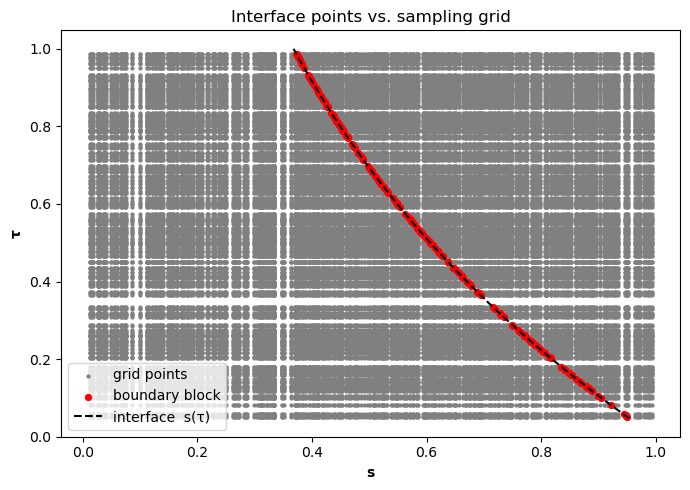

In [25]:
# Sanity Check
import matplotlib.pyplot as plt

# dense interface curve for reference
tau_dense = torch.linspace(tau_lo, tau_hi, 400, device=device, dtype=torch.float64)
s_curve   = torch.exp((-z_val*(z_val+1))/(2*(1/tau_dense) + z_val - 1))

plt.figure(figsize=(7,5))
# full grid points
plt.scatter(S.reshape(-1).cpu(), TAU.reshape(-1).cpu(),
            s=4, c='gray', label='grid points')
# the boundary block you injected
plt.scatter(s_b.cpu(), tau_b.cpu(),
            s=18, c='red', label='boundary block')
# analytic interface curve
plt.plot(s_curve.cpu(), tau_dense.cpu(),
         'k--', lw=1.5, label='interface  s(τ)')

plt.xlabel('s', fontweight='bold')
plt.ylabel('τ', fontweight='bold')
plt.title('Interface points vs. sampling grid')
plt.legend()
plt.tight_layout()
plt.show()

## Save your Data

In [26]:
import os
os.makedirs('./data', exist_ok=True)

# ---------- helper to assemble a dict from flats ----------
def make_dict(s_f, tau_f, w_f):
    n = s_f.numel()
    return {
        'stau':   torch.stack([s_f, tau_f], dim=1).to(device=device, dtype=torch.float64),
        'W':      w_f.reshape(-1, 1).to(device=device, dtype=torch.float64),
        'kratio': torch.full((n,), k1 / k2, dtype=torch.float64, device=device),
        'zdis':   torch.full((n,), z_dis,   dtype=torch.float64, device=device),
    }

# ---------- 1) CLEAN grid only (no boundary) ----------
print("\n[6a] SAVING CLEAN GRID (4 keys)")
grid_dict = make_dict(s_flat, tau_flat, w_flat)
print('clean W shape:', grid_dict['W'].shape)
torch.save(grid_dict, f'./data/2layer_interpol_ns{n_s}.pt')

# ---------- 2) AUGMENTED: append the interface curve TWICE ----------
print("\n[6b] SAVING AUGMENTED (grid + 2x interface)")
s_aug   = torch.cat([s_flat,   s_b,   s_b])
tau_aug = torch.cat([tau_flat, tau_b, tau_b])
w_aug   = torch.cat([w_flat,   W_b,   W_b])

aug_dict = make_dict(s_aug, tau_aug, w_aug)
print('augmented W shape:', aug_dict['W'].shape)
torch.save(aug_dict, f'./data/2layer_interpol_ns{n_s}_aug.pt')


[6a] SAVING CLEAN GRID (4 keys)
clean W shape: torch.Size([80000, 1])

[6b] SAVING AUGMENTED (grid + 2x interface)
augmented W shape: torch.Size([80400, 1])
